In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_excel('2025-2-19公众号Python机器学习AI.xlsx')
df 

,infP,infC,infAc,infpro,infS,MLSS,MLVSS,VSS/TSS,volumn,ana-time,pH,T,salinity,SR
0,12.57,70.32,70.32,0.00,166.17,6.15,3.07,0.50,10.0,6.0,8.0,22,0.09,34.45
1,9.29,67.40,67.40,0.00,135.80,8.48,4.82,0.57,20.0,12.0,7.4,30,0.70,8.22
2,9.04,67.40,67.40,0.00,135.80,8.67,5.94,0.69,20.0,12.0,7.4,30,0.70,18.67
3,10.36,85.00,52.01,32.99,155.14,9.60,6.91,0.72,0.5,0.3,7.5,30,0.70,3.06
4,11.21,74.84,74.84,0.00,209.74,4.83,2.38,0.49,10.0,6.0,8.0,22,0.09,70.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
550,6.54,52.60,52.60,0.00,117.24,3.10,2.40,0.77,4.0,2.0,7.4,20,0.05,11.03
551,9.88,74.70,74.70,0.00,224.10,7.70,4.60,0.60,20.0,6.0,7.5,30,1.00,28.27
552,11.43,67.74,67.74,0.00,190.81,5.41,2.79,0.51,10.0,6.0,8.0,22,0.09,54.24
553,9.62,78.40,78.40,0.00,235.19,7.70,4.60,0.60,20.0,6.0,7.5,30,1.00,21.79


In [6]:
import seaborn as sns
from matplotlib.patches import Wedge
# 计算相关系数矩阵
corr = df.corr()

# 创建图形
fig, ax = plt.subplots(figsize=(10, 8), dpi=1200)
cmap = plt.cm.viridis
norm = plt.Normalize(vmin=-1, vmax=1)

# 循环绘制饼图（下三角部分）和数值（上三角部分）
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        if i > j:  # 下三角部分，绘制饼图
            coeff = corr.iloc[i, j]  # 相关系数
            abs_coeff = np.abs(coeff)  # 相关系数的绝对值

            # 设置饼图的起始角度和结束角度（有色部分表示相关性大小）
            start_angle = 90  # 起始角度
            end_angle = 90 + abs_coeff * 360  # 结束角度

            # 计算中心点位置
            x, y = i, j

            # 添加扇形（饼图效果）
            wedge = Wedge(center=(x, y), r=0.4, theta1=start_angle, theta2=end_angle,
                          facecolor=cmap(norm(coeff)), edgecolor='black', alpha=0.75)
            ax.add_patch(wedge)

            # 填充背景（无色部分）
            bg_wedge = Wedge(center=(x, y), r=0.4, theta1=end_angle, theta2=start_angle + 360,
                             facecolor='white', edgecolor='black', alpha=0.5)
            ax.add_patch(bg_wedge)
        elif i < j:  # 上三角部分，显示数值
            coeff = corr.iloc[i, j]
            color = cmap(norm(coeff))  # 数值的颜色基于相关系数
            ax.text(i, j, f'{coeff:.2f}', ha='center', va='center', color=color, fontsize=10)
        elif i == j:  # 对角线部分，显示空白
            ax.scatter(i, j, s=1, color='white')

# 设置坐标轴标签
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=10)
ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns, fontsize=10)

# 添加颜色条
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # 仅用于显示颜色条
fig.colorbar(sm, ax=ax, label='Correlation Coefficient')

# 添加标题和布局调整
plt.tight_layout()
plt.savefig("1.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [7]:
from sklearn.model_selection import train_test_split
# 划分特征和目标变量
X = df.drop(['SR'], axis=1)
y = df['SR']
# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                    random_state=42)

随机森林 (Random Forest)	多棵树并行工作，民主投票。	“集思广益”。每棵树独立在数据的随机子集上训练，最后投票决定结果，以降低方差。  
XGBoost (Gradient Boosting)	多棵树串行工作，接力修正。	“精益求精”。每棵树都在前一棵树的错误基础上进行学习，不断迭代，以降低偏差。  

In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import mean_squared_error, r2_score

# 定义 XGBoost 回归模型
model_xgb = XGBRegressor(use_label_encoder=False, eval_metric='rmse', random_state=8)

# 定义参数网格
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# 使用 K 折交叉验证
kfold = KFold(n_splits=5, shuffle=True, random_state=8)

# 使用网格搜索寻找最佳参数
grid_search = GridSearchCV(estimator=model_xgb, param_grid=param_grid, scoring='neg_mean_squared_error',
                           cv=kfold, verbose=1, n_jobs=1)

# 拟合模型
grid_search.fit(X_train, y_train)
# 使用最优参数训练模型
xgboost = grid_search.best_estimator_
# 输出最佳参数和最佳分数
print("Best Parameters:", grid_search.best_params_)
print("Best CV RMSE:", (-grid_search.best_score_)**0.5)  # 计算 RMSE(均方根误差)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
Best CV RMSE: 9.711614812208364


In [9]:
import sys
import os
# 将标准输出重定向到os.devnull
sys.stdout = open(os.devnull, 'w')
import shap
explainer = shap.TreeExplainer(xgboost)
shap_values = explainer.shap_values(X_test)

In [10]:
plt.figure(figsize=(10, 5), dpi=1200)
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title('SHAP_numpy Sorted Feature Importance')
plt.tight_layout()
plt.savefig("2.pdf", format='pdf',bbox_inches='tight')
plt.show()

In [11]:
# 假设 X_test 是一个 Pandas DataFrame
feature_importance = np.mean(np.abs(shap_values), axis=0)

# 创建一个 DataFrame，将列名设置为 X_test 的特征名
feature_importance_df = pd.DataFrame({
    'Feature': X_test.columns,  # 使用 X_test 的特征名
    'Importance': feature_importance  # 对应的均值
}).sort_values(by='Importance', ascending=False)  # 按重要性降序排序
feature_importance_df

,Feature,Importance
7,VSS/TSS,18.160166
9,ana-time,3.973746
4,infS,2.713618
5,MLSS,2.408689
1,infC,1.550664
10,pH,1.491455
0,infP,1.364842
2,infAc,1.291540
6,MLVSS,1.197442
8,volumn,0.465637


In [12]:
import numpy as np
import pandas as pd

# 假设 X_test 是一个 Pandas DataFrame，shap_values 是 SHAP 值
feature_importance = np.mean(np.abs(shap_values), axis=0)

# 创建一个 DataFrame，将列名设置为 X_test 的特征名
feature_importance_df = pd.DataFrame({
    'Feature': X_test.columns,  # 使用 X_test 的特征名
    'Importance': feature_importance  # 对应的均值
}).sort_values(by='Importance', ascending=False)  # 按重要性降序排序

# 计算特征重要性的百分比占比
total_importance = feature_importance_df['Importance'].sum()  # 所有特征重要性的总和
feature_importance_df['Percentage'] = (feature_importance_df['Importance'] / total_importance) * 100
feature_importance_df

,Feature,Importance,Percentage
7,VSS/TSS,18.160166,51.532005
9,ana-time,3.973746,11.276059
4,infS,2.713618,7.700271
5,MLSS,2.408689,6.834993
1,infC,1.550664,4.400225
10,pH,1.491455,4.232212
0,infP,1.364842,3.872931
2,infAc,1.291540,3.664925
6,MLVSS,1.197442,3.397908
8,volumn,0.465637,1.321311


针对完整数据集计算相关系数，shap是针对测试集，自己进行选择也可以相关系数也对测试集

In [ ]:
# 计算相关系数矩阵
corr = df.corr()

# 提取目标变量 'SR' 与其他特征的相关系数
corr_with_target = corr['SR'].drop('SR')  # 排除目标变量本身
# 你现在拿到了一列数据，它显示了“总评”和其他所有特征（包括它自己）的相关性
# drop('SR')刚刚抽出来的那一列数据里，有一个‘总评 vs 总评’的记录，它的值是1，这没什么意义，帮我把它删掉

# 将相关系数添加到 feature_importance_df 中
feature_importance_df['SR_Correlation'] = feature_importance_df['Feature'].map(corr_with_target)
feature_importance_df

,Feature,Importance,Percentage,SR_Correlation
7,VSS/TSS,18.160166,51.532005,-0.821875
9,ana-time,3.973746,11.276059,0.395748
4,infS,2.713618,7.700271,0.304319
5,MLSS,2.408689,6.834993,0.345671
1,infC,1.550664,4.400225,-0.233599
10,pH,1.491455,4.232212,0.458628
0,infP,1.364842,3.872931,-0.139735
2,infAc,1.291540,3.664925,0.455957
6,MLVSS,1.197442,3.397908,-0.491230
8,volumn,0.465637,1.321311,-0.044808


这里其实采用'SR_Correlation'是一个非常好的方法，之前我们的笔记中不是很详细的介绍了怎么确定某个特征变量对结局变量到底是正相关还是负相关吗  
这里直接采用'SR_Correlation'相关性方法就可以很好的解决这个问题，也不用看什么散点图，小提琴图了  

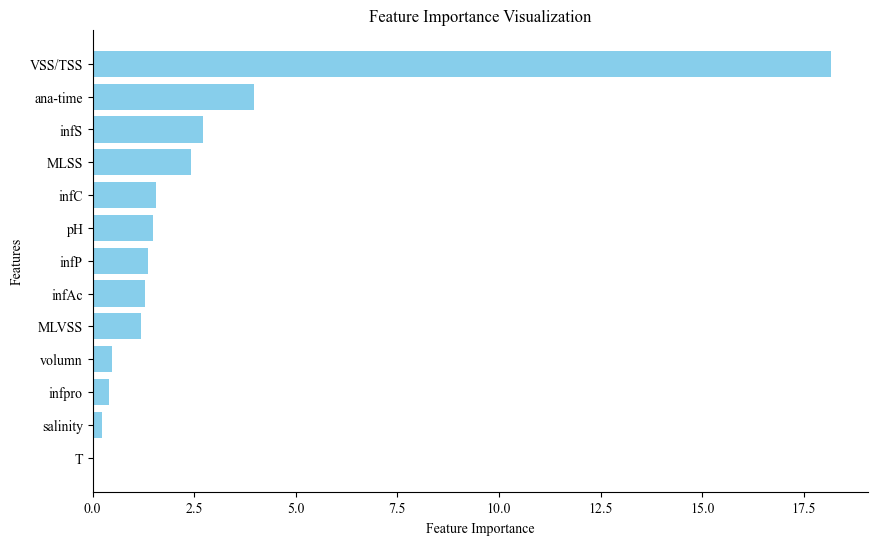

In [14]:
# 按照 'Importance' 列降序排序
feature_importance_df_sorted = feature_importance_df.sort_values(by='Importance', ascending=True)

# 绘制柱状图
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df_sorted['Feature'], feature_importance_df_sorted['Importance'], color='skyblue')

# 设置轴标签和标题
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Feature Importance Visualization')

# 关闭右边和顶部的边框
ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# 显示图表
plt.show()

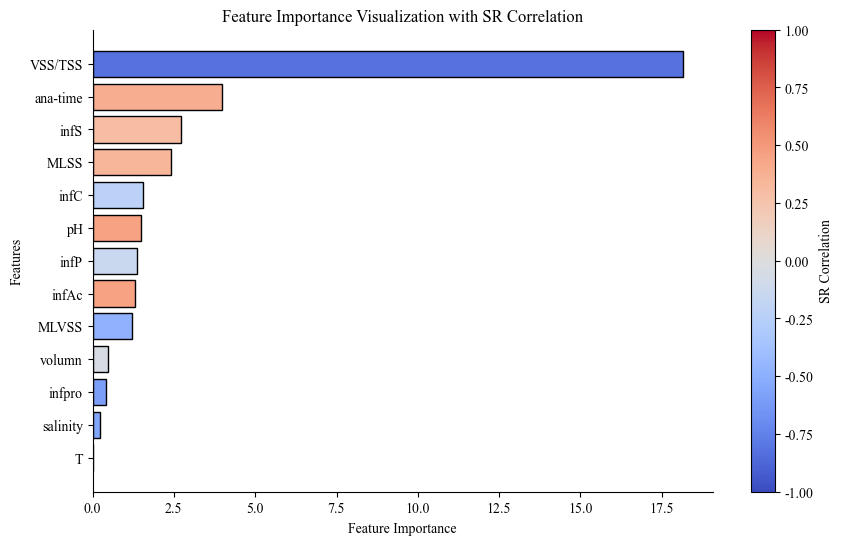

In [ ]:
# 按照 'Importance' 列降序排序
feature_importance_df_sorted = feature_importance_df.sort_values(by='Importance', ascending=True)

# 创建一个颜色映射，根据相关系数来设置颜色
norm = plt.Normalize(vmin=-1, vmax=1)  # 将颜色映射的范围设置为 -1 到 1
cmap = plt.get_cmap("coolwarm")  # 使用"coolwarm"色带，当然也可以选择其他色带

# 绘制柱状图
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(feature_importance_df_sorted['Feature'], feature_importance_df_sorted['Importance'], 
               color=cmap(norm(feature_importance_df_sorted['SR_Correlation'])), edgecolor='black')

# 设置轴标签和标题
ax.set_xlabel('Feature Importance')
ax.set_ylabel('Features')
ax.set_title('Feature Importance Visualization with SR Correlation')

# 去除右边和顶部的边框
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# 添加颜色条 (colorbar)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # 为空数组以创建colorbar
fig.colorbar(sm, ax=ax, label='SR Cor
relation')

# 显示图表
plt.show()

In [ ]:
# 按照 'Importance' 列降序排序
feature_importance_df_sorted = feature_importance_df.sort_values(by='Importance', ascending=True)

# 创建一个颜色映射，根据相关系数来设置颜色
norm = plt.Normalize(vmin=-1, vmax=1)  # 将颜色映射的范围设置为 -1 到 1
cmap = plt.get_cmap("coolwarm")  # 使用"coolwarm"色带，当然也可以选择其他色带

# 绘制柱状图
fig, ax = plt.subplots(figsize=(10, 6), dpi=1200)
bars = ax.barh(feature_importance_df_sorted['Feature'], feature_importance_df_sorted['Importance'], 
               color=cmap(norm(feature_importance_df_sorted['SR_Correlation'])))
# norm 是我们之前创建的“归一化”对象。它的作用是把一个范围不固定的数值（比如-1到+1），映射到一个标准的 0.0 到 1.0 的范围。
# 是什么：cmap 是我们之前创建的“颜色映射”对象。它就像一个函数，你给它一个 0.0 到 1.0 之间的数，它会返回一个具体的颜色。
# 工作流程：cmap 接收来自 norm 的输出（0.0到1.0的列表），然后为每个数字匹配一个颜色。
# 输入 0.0，它可能返回冷色调（比如深蓝色）。
# 输入 0.5，它可能返回中间色调（比如白色或黄色）。
# 输入 1.0，它可能返回暖色调（比如鲜红色）。
# 设置轴标签和标题
ax.set_xlabel('mean(SHAP value|)(average impact on model output magnitude)', fontweight='bold', fontsize=14)  # 设置x轴标签并加粗、增大字体
ax.set_ylabel('Features', fontweight='bold', fontsize=14)  # 设置y轴标签并加粗、增大字体
ax.set_title('Feature Importance Visualization with SR Correlation', fontweight='bold', fontsize=16)  # 设置标题并加粗、增大字体

ax.tick_params(axis='x', labelsize=12, labelcolor='black', length=6)
ax.tick_params(axis='y', labelsize=12, labelcolor='black', length=6)

# 去除右边和顶部的边框
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# 添加颜色条 (colorbar)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # 为空数组以创建colorbar
cbar = fig.colorbar(sm, ax=ax, label='SR Correlation', pad=0.13)  # 增加 pad 参数稍微向右移动颜色条

# 为每个柱状图添加相关系数和占比的实际值
for i, bar in enumerate(bars):
    # 获取相关系数和占比的值
    correlation = feature_importance_df_sorted.iloc[i]['SR_Correlation']
    percentage = feature_importance_df_sorted.iloc[i]['Percentage']
    
    # 在柱状图上添加文本（相关系数和占比）
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,  # 在 bar.get_width() 上加上一个常数值
            f"r = {correlation:.3f} {percentage:.2f}%",
            va='center', ha='left', color='black', fontsize=10, fontweight='bold')  # 加粗文本，居中，左齐

plt.savefig("3.pdf", format='pdf',bbox_inches='tight')
plt.show()